In [1]:
# ── Unzip and Locate Data ──
!unzip -q -o /content/Episodes.zip -d /content/episodes_data
!find /content/episodes_data -name "*.csv" | head -n 6

/content/episodes_data/Episodes/WorkloadAwareThreshold/transitions_20260309_145154.csv
/content/episodes_data/Episodes/WorkloadAwareThreshold/transitions_20260311_005203.csv
/content/episodes_data/Episodes/PartitionExploration/transitions_20260309_204515.csv
/content/episodes_data/Episodes/PartitionExploration/transitions_20260311_002742.csv
/content/episodes_data/Episodes/Random_Partition/transitions_20260311_000523.csv
/content/episodes_data/Episodes/Random_Partition/transitions_20260309_213422.csv


In [2]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# Setup Output Directory
if Path('/kaggle').exists():
    OUTPUT_DIR = Path('/kaggle/working/lakegym_partition_agent')
elif Path('/content').exists():
    OUTPUT_DIR = Path('/content')
else:
    OUTPUT_DIR = Path('/content')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_GLOBS =[
    '/kaggle/input/**/*.csv',
    '/kaggle/working/**/*.csv',
    '/content/episodes_data/Episodes/**/*.csv'
]

TensorFlow Version: 2.19.0


In [3]:

# --- Environment Constants ---
LATENCY_MAX = 15000.0
FILE_COUNT_MAX = 2000.0
PARTITION_COST_MAX = 2.0
SKEW_MAX = 2.0

# ACTION_MAP -> 0: NOOP, 4: HOUR, 5: REGION, 6: TYPE, 7: REMOVE
ACTION_COSTS_PARTITION = {0: 0.0, 4: 2.0, 5: 2.0, 6: 2.0, 7: 0.7}

# Partition Reward Weights
PW_PRUNING = 0.55
PW_DELTA = 0.25
PW_SKEW = 0.10
PW_COST = 0.10

# Global Reward Weights
GW_LATENCY = 0.30
GW_FILES = 0.20
GW_PRUNING = 0.30
GW_UTIL = 0.20

def recompute_partition_rewards_vectorized(df):
    """
    Highly optimized, vectorized recomputation matching LakeGym v5.2 specs.
    """
    d = df.copy()

    # Extract base features, defaulting to 0.0
    a = d['action'].fillna(0).astype(int)
    cost = a.map(ACTION_COSTS_PARTITION).fillna(0.0)

    fc = d.get('next_file_count', d.get('file_count', 0.0)).astype(float)
    lat = d.get('next_latency_ms', d.get('latency_ms', 0.0)).astype(float)
    util = d.get('next_block_utilization', d.get('block_utilization', 0.0)).astype(float)
    skew = d.get('file_size_skew_kb', 0.0).astype(float)

    prune_curr = d.get('partition_pruning_ratio', 0.0).astype(float)
    prune_next = d.get('next_partition_pruning_ratio', prune_curr).astype(float)

    # Calculate Norms
    f_norm = (fc / FILE_COUNT_MAX).clip(0.0, 1.0)
    l_norm = (lat / LATENCY_MAX).clip(0.0, 1.0)
    u_norm = util.clip(0.0, 1.0)
    s_norm = (skew / SKEW_MAX).clip(0.0, 1.0)

    p_norm = prune_next.clip(0.0, 1.0)
    delta_p = (prune_next - prune_curr).clip(-1.0, 1.0)
    c_norm = (cost / PARTITION_COST_MAX).clip(0.0, 1.0)

    # LakeGym v5.2 Partition Reward: R_p = 0.55*p_norm + 0.25*delta_p - 0.10*s_norm - 0.10*c_norm
    d['partition_reward'] = (PW_PRUNING * p_norm) + (PW_DELTA * delta_p) - (PW_SKEW * s_norm) - (PW_COST * c_norm)

    # LakeGym v5.2 Global Reward: R_g = -0.30*l_norm - 0.20*f_norm + 0.30*p_norm + 0.20*u_norm
    d['global_reward'] = -(GW_LATENCY * l_norm) - (GW_FILES * f_norm) + (GW_PRUNING * p_norm) + (GW_UTIL * u_norm)

    # Tag for verification
    d['reward_preset'] = 'v5_2_recomputed'

    return d

# --- Load and Process Data ---
files =[]
for p in DATA_GLOBS:
    files.extend(glob.glob(p, recursive=True))
files =[f for f in sorted(set(files)) if f.endswith('.csv') and 'transitions' in Path(f).name]

if not files:
    raise RuntimeError("No CSV files found. Check your DATA_GLOBS paths.")

print(f"Found {len(files)} CSV files. Loading...")
raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# CRITICAL: Sort by policy and step to maintain timeline integrity before windowing
sort_cols =[c for c in ['policy_name', 'episode', 'step'] if c in raw.columns]
if sort_cols:
    raw = raw.sort_values(sort_cols).reset_index(drop=True)

# Recompute base rewards on the ENTIRE timeline BEFORE filtering out compaction actions
df = recompute_partition_rewards_vectorized(raw)

processed_path = 'partition_transitions_recomputed.csv'
df.to_csv(processed_path, index=False)
print(f"Recomputed rewards for {len(df)} total transitions. Saved to: {processed_path}")

Found 6 CSV files. Loading...
Recomputed rewards for 6000 total transitions. Saved to: partition_transitions_recomputed.csv


In [4]:
NUM_ACTIONS = 5   # NOOP, HOUR, REGION, EVENT_TYPE, REMOVE
NUM_FEATURES = 14
WINDOW_SIZE = 20
EPISODE_LENGTH = 1000 # Your defined episode length

ACTION_MAP = {0: 0, 4: 1, 5: 2, 6: 3, 7: 4}
REVERSE_MAP = {v: k for k, v in ACTION_MAP.items()}
ACTION_NAMES =['NOOP', 'HOUR', 'REGION', 'EVENT_TYPE', 'REMOVE']

def extract_partition_features(df_target, prefix=''):
    p = prefix
    f = np.zeros((len(df_target), NUM_FEATURES), dtype=np.float32)
    f[:, 0] = np.clip(df_target[f'{p}latency_ms'].values / 15000.0, 0, 1)
    f[:, 1] = np.clip(df_target[f'{p}file_count'].values / 2000.0, 0, 1)
    ps = df_target[f'{p}partition_strategy'].values.astype(int)
    for i in range(4):
        f[:, 2+i] = (ps == i).astype(np.float32)
    f[:, 6] = np.clip(df_target[f'{p}partition_pruning_ratio'].values, 0, 1)
    f[:, 7] = np.clip(df_target[f'{p}avg_pruning_ratio'].values, 0, 1)
    f[:, 8] = df_target[f'{p}query_hist_time_range'].values
    f[:, 9] = df_target[f'{p}query_hist_region_filter'].values
    f[:, 10] = df_target[f'{p}query_hist_sensor_lookup'].values
    f[:, 11] = df_target[f'{p}query_hist_type_filter'].values
    f[:, 12] = df_target[f'{p}query_hist_full_scan'].values
    f[:, 13] = np.exp(-df_target[f'{p}steps_since_partition_change'].values / 30.0)
    return f

# 1. Extract features for the ENTIRE timeline (all 6000 steps)
features_full = extract_partition_features(df)
N_TOTAL = len(df)
windows_full = np.zeros((N_TOTAL, WINDOW_SIZE, NUM_FEATURES), dtype=np.float32)

# 2. Build windows safely, respecting the 1000-step experiment limits
for start_idx in range(0, N_TOTAL, EPISODE_LENGTH):
    end_idx = min(start_idx + EPISODE_LENGTH, N_TOTAL)
    ep_features = features_full[start_idx:end_idx]

    ep_N = len(ep_features)
    for i in range(ep_N):
        s = max(0, i - WINDOW_SIZE + 1)
        seq = ep_features[s:i+1]
        pad = WINDOW_SIZE - len(seq)
        windows_full[start_idx + i, pad:, :] = seq

# 3. Now it is safe to mask down to only partition actions (and NOOPs)
mask = df['action'].isin(ACTION_MAP.keys()).values
df_part = df[mask].reset_index(drop=True)
windows = windows_full[mask]
actions = np.array([ACTION_MAP[a] for a in df_part['action'].values], dtype=np.int32)

print(f"Total raw steps processed: {N_TOTAL}")
print(f"Valid partition transitions extracted: {len(df_part)}")
print(f"State Window Shape: {windows.shape}")
print("\nPartition action breakdown:")
for i, name in enumerate(ACTION_NAMES):
    count = (actions == i).sum()
    print(f"  {name}: {count} ({count/len(actions)*100:.1f}%)")

Total raw steps processed: 6000
Valid partition transitions extracted: 4990
State Window Shape: (4990, 20, 14)

Partition action breakdown:
  NOOP: 3570 (71.5%)
  HOUR: 371 (7.4%)
  REGION: 350 (7.0%)
  EVENT_TYPE: 363 (7.3%)
  REMOVE: 336 (6.7%)


In [5]:
# Physical improvements
lat_before  = df_part['latency_ms'].values.astype(np.float32)
lat_after   = df_part['next_latency_ms'].values.astype(np.float32)
lat_improvement = np.clip((lat_before - lat_after) / (lat_before + 1.0), -1, 1)

prune_before = df_part['partition_pruning_ratio'].values.astype(np.float32)
prune_after  = df_part['next_partition_pruning_ratio'].values.astype(np.float32)
prune_improvement = np.clip(prune_after - prune_before, -1, 1)

# Workload-partition alignment (Detects the 50-step / 200-step phases)
qh = np.column_stack([
    df_part['query_hist_time_range'].values,      # 0
    df_part['query_hist_region_filter'].values,   # 1
    df_part['query_hist_sensor_lookup'].values,   # 2
    df_part['query_hist_type_filter'].values,     # 3
]).astype(np.float32)

dominant_query    = np.argmax(qh, axis=-1)
dominant_strength = np.max(qh, axis=-1)

# Ideal mapping based on workload profiles
ideal_action = np.zeros(len(actions), dtype=np.int32)
ideal_action[dominant_query == 0] = 1   # time_heavy -> HOUR
ideal_action[dominant_query == 1] = 2   # region_heavy -> REGION
ideal_action[dominant_query == 3] = 3   # type_heavy -> EVENT_TYPE

current_ps = df_part['partition_strategy'].values.astype(int)
already_correct = (current_ps == ideal_action) & (ideal_action > 0)

alignment = np.zeros(len(actions), dtype=np.float32)

# Case A: Partition ALREADY matches workload
mask_ok = already_correct
alignment[mask_ok & (actions == 0)]  =  0.5   # NOOP is correct behavior
alignment[mask_ok & (actions == 4)]  = -0.8   # REMOVE is punished
for a in [1, 2, 3]:
    alignment[mask_ok & (actions == a) & (actions != ideal_action)] = -0.5

# Case B: Partition DOESN'T match workload
mask_bad = ~already_correct
for a in [1, 2, 3]:
    match = mask_bad & (actions == a) & (ideal_action == a)
    alignment[match] = 1.0

alignment[mask_bad & (actions == 0)] = -0.3    # NOOP when out-of-sync is bad
alignment[mask_bad & (actions == 4) & (current_ps > 0)] = 0.3 # REMOVE wrong partition

# Scale alignment importance by how dominant the query profile currently is
clarity = np.clip(dominant_strength * 2.5 - 0.5, 0.3, 1.5)
alignment *= clarity

# Final Blend
OUTCOME_WEIGHT    = 0.3
ALIGNMENT_WEIGHT  = 0.5
GLOBAL_WEIGHT     = 0.2

base_global = df_part['global_reward'].values.astype(np.float32)
custom_rewards = (
    OUTCOME_WEIGHT   * (0.5 * lat_improvement + 0.5 * prune_improvement) +
    ALIGNMENT_WEIGHT * alignment +
    GLOBAL_WEIGHT    * base_global
).astype(np.float32)

# Per-action standardized advantages (AWAC/AWR requirement)
advantages = custom_rewards.copy()
for a_idx in range(NUM_ACTIONS):
    m = actions == a_idx
    if m.sum() > 1:
        advantages[m] = (advantages[m] - advantages[m].mean()) / (advantages[m].std() + 1e-8)

print(f"Outcome-based signals configured. Global Max Adv: {advantages.max():.2f}")

Outcome-based signals configured. Global Max Adv: 3.60


In [6]:
class AttentivePPO(tf.keras.Model):
    def __init__(self, num_actions, num_features, window_size=20, embed_dim=64, num_heads=4):
        super().__init__()
        self.embedding = tf.keras.layers.Dense(embed_dim, activation='relu', name='embedding')
        self.pos_encoding = self.add_weight(name='pos_encoding', shape=(1, window_size, embed_dim),
                                            initializer='glorot_uniform', trainable=True)
        self.attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim,
                                                            dropout=0.1, name='self_attention')
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name='norm1')
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name='norm2')
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(embed_dim * 2, activation='relu', name='ffn_dense1'),
            tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(embed_dim, name='ffn_dense2'),
        ], name='ffn')
        self.gap = tf.keras.layers.GlobalAveragePooling1D(name='gap')
        self.actor = tf.keras.layers.Dense(num_actions, activation='softmax', name='actor')
        self.critic = tf.keras.layers.Dense(1, name='critic')

    def call(self, x, training=False):
        embedded = self.embedding(x) + self.pos_encoding
        attn_output = self.attention(embedded, embedded, training=training)
        x1 = self.norm1(embedded + attn_output)
        ffn_output = self.ffn(x1, training=training)
        x2 = self.norm2(x1 + ffn_output)
        context = self.gap(x2)
        return self.actor(context), self.critic(context)

policy_model = AttentivePPO(NUM_ACTIONS, NUM_FEATURES, WINDOW_SIZE)
policy_model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES))) # Dummy pass
policy_model.summary()

Model: "attentive_ppo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Dense)               │ (1, 20, 64)            │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention                  │ (1, 20, 64)            │        66,368 │
│ (MultiHeadAttention)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm1 (LayerNormalization)      │ (1, 20, 64)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm2 (LayerNormalization)      │ (1, 20, 64)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ffn (Sequential)                │ (1, 20, 64)            │        16,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ actor (Dense)                   │ (1, 5)                 │           325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ critic (Dense)                  │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,830 (335.27 KB)

 Trainable params: 85,830 (335.27 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
BETA          = 1.0
LR_POLICY     = 3e-4
EPOCHS_POLICY = 200
ENTROPY_COEFF = 0.10
BATCH_SIZE    = 64

# Balanced sampling setup
action_indices = {a: np.where(actions == a)[0] for a in range(NUM_ACTIONS)}
samples_per_action = min(len(v) for v in action_indices.values())
print(f"Balanced Sampling: {samples_per_action}/action × {NUM_ACTIONS} = {samples_per_action * NUM_ACTIONS}/epoch")

policy_opt = tf.keras.optimizers.Adam(LR_POLICY)
eval_idx = np.arange(0, len(windows), max(1, len(windows) // 200))[:200]

policy_history = {'loss': [], 'entropy': [], 'actor_loss':[]}

for epoch in range(EPOCHS_POLICY):
    # Stratified sampling
    balanced_idx = np.concatenate([
        np.random.choice(action_indices[a], size=samples_per_action, replace=True)
        for a in range(NUM_ACTIONS)
    ])
    np.random.shuffle(balanced_idx)

    el, ee, ea, nb = 0., 0., 0., 0
    for start in range(0, len(balanced_idx), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(balanced_idx))
        bi = balanced_idx[start:end]

        w_b   = tf.constant(windows[bi])
        a_b   = tf.constant(actions[bi])
        adv_b = tf.constant(advantages[bi])
        ret_b = tf.constant(custom_rewards[bi], dtype=tf.float32)

        with tf.GradientTape() as tape:
            probs, values = policy_model(w_b, training=True)

            weights = tf.minimum(tf.exp(adv_b / BETA), 20.0)

            log_p  = tf.math.log(probs + 1e-8)
            sel_lp = tf.reduce_sum(log_p * tf.one_hot(a_b, NUM_ACTIONS), axis=-1)
            actor_loss = -tf.reduce_mean(weights * sel_lp)

            entropy   = -tf.reduce_sum(probs * log_p, axis=-1)
            ent_bonus = ENTROPY_COEFF * tf.reduce_mean(entropy)

            critic_loss = tf.reduce_mean(tf.square(tf.squeeze(values, -1) - ret_b))

            loss = actor_loss + 0.5 * critic_loss - ent_bonus

        grads = tape.gradient(loss, policy_model.trainable_variables)
        policy_opt.apply_gradients(zip(grads, policy_model.trainable_variables))

        el += float(loss)
        ee += float(tf.reduce_mean(entropy))
        ea += float(actor_loss)
        nb += 1

    policy_history['loss'].append(el / nb)
    policy_history['entropy'].append(ee / nb)
    policy_history['actor_loss'].append(ea / nb)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        cp, _ = policy_model(tf.constant(windows[eval_idx]), training=False)
        cpred = np.argmax(cp.numpy(), axis=-1)
        ds = ", ".join(f"{ACTION_NAMES[i]}:{(cpred==i).mean()*100:.0f}%" for i in range(NUM_ACTIONS))
        print(f"Epoch {epoch+1:03d}/{EPOCHS_POLICY} | Loss: {policy_history['loss'][-1]:.4f} | Ent: {policy_history['entropy'][-1]:.3f} | Dist:[{ds}]")

policy_model.save_weights(OUTPUT_DIR / 'offline_partition_agent.weights.h5')
print("Model Saved.")

Balanced Sampling: 336/action × 5 = 1680/epoch
Epoch 001/200 | Loss: 2.8629 | Ent: 1.505 | Dist:[NOOP:38%, HOUR:22%, REGION:34%, EVENT_TYPE:0%, REMOVE:6%]
Epoch 010/200 | Loss: 1.7886 | Ent: 1.200 | Dist:[NOOP:52%, HOUR:22%, REGION:11%, EVENT_TYPE:16%, REMOVE:0%]
Epoch 020/200 | Loss: 1.6501 | Ent: 1.140 | Dist:[NOOP:52%, HOUR:14%, REGION:14%, EVENT_TYPE:16%, REMOVE:4%]
Epoch 030/200 | Loss: 1.5280 | Ent: 1.128 | Dist:[NOOP:51%, HOUR:14%, REGION:12%, EVENT_TYPE:14%, REMOVE:10%]
Epoch 040/200 | Loss: 1.5151 | Ent: 1.092 | Dist:[NOOP:53%, HOUR:15%, REGION:8%, EVENT_TYPE:16%, REMOVE:8%]
Epoch 050/200 | Loss: 1.4648 | Ent: 1.094 | Dist:[NOOP:55%, HOUR:14%, REGION:14%, EVENT_TYPE:10%, REMOVE:8%]
Epoch 060/200 | Loss: 1.4098 | Ent: 1.104 | Dist:[NOOP:56%, HOUR:12%, REGION:8%, EVENT_TYPE:9%, REMOVE:14%]
Epoch 070/200 | Loss: 1.3633 | Ent: 1.061 | Dist:[NOOP:54%, HOUR:14%, REGION:8%, EVENT_TYPE:8%, REMOVE:15%]
Epoch 080/200 | Loss: 1.2325 | Ent: 1.035 | Dist:[NOOP:56%, HOUR:14%, REGION:13%, EV

In [8]:
policy_model.save_weights('offline_partition_agent.weights.h5')


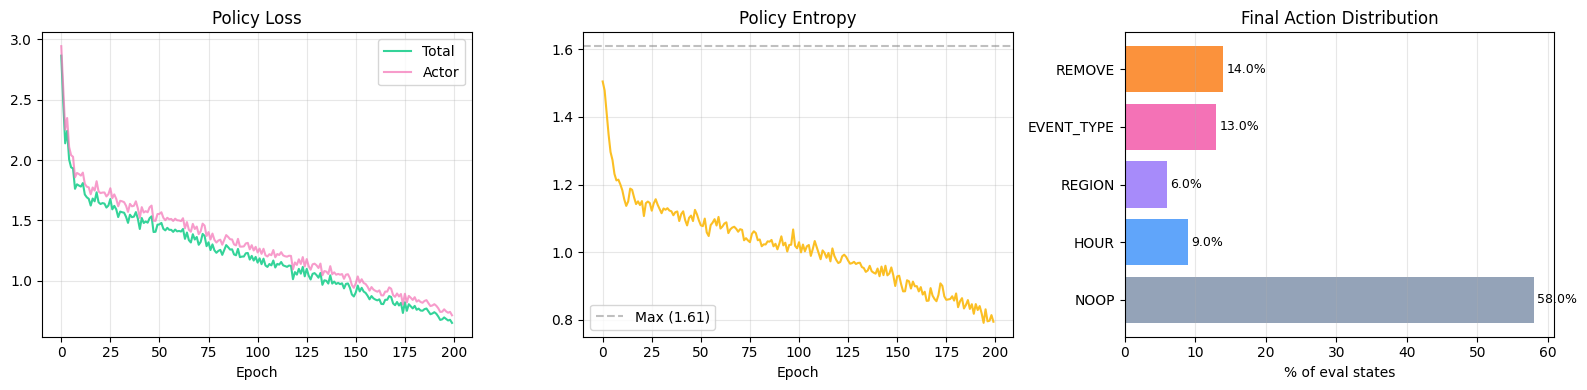


── Workload Response Verification ──
When time_range           dominates ( 68 states): [NOOP:59% | HOUR:16% | REGION:1% | EVENT_TYPE:10% | REMOVE:13%]  (Ideal mapping: HOUR)
When region_filter        dominates ( 57 states): [NOOP:53% | HOUR:7% | REGION:12% | EVENT_TYPE:11% | REMOVE:18%]  (Ideal mapping: REGION)
When sensor_lookup        dominates ( 12 states): [NOOP:58% | HOUR:8% | REGION:8% | EVENT_TYPE:8% | REMOVE:17%]  (Ideal mapping: NOOP)
When type_filter          dominates ( 63 states): [NOOP:62% | HOUR:3% | REGION:5% | EVENT_TYPE:19% | REMOVE:11%]  (Ideal mapping: EVENT_TYPE)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(policy_history['loss'], color='#34d399', label='Total')
axes[0].plot(policy_history['actor_loss'], color='#f472b6', alpha=0.7, label='Actor')
axes[0].set_title('Policy Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(policy_history['entropy'], color='#fbbf24')
axes[1].axhline(y=np.log(NUM_ACTIONS), color='gray', ls='--', alpha=0.5, label=f'Max ({np.log(NUM_ACTIONS):.2f})')
axes[1].set_title('Policy Entropy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

cp_all, _ = policy_model(tf.constant(windows[eval_idx]), training=False)
cp_pred = np.argmax(cp_all.numpy(), axis=-1)
action_pcts =[(cp_pred == i).mean() * 100 for i in range(NUM_ACTIONS)]
axes[2].barh(ACTION_NAMES, action_pcts, color=['#94a3b8', '#60a5fa', '#a78bfa', '#f472b6', '#fb923c'])
axes[2].set_title('Final Action Distribution'); axes[2].set_xlabel('% of eval states')
for i, pct in enumerate(action_pcts):
    axes[2].text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=9)
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'partition_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Workload Conditional Analysis
print("\n── Workload Response Verification ──")
eval_qh = np.column_stack([
    df_part['query_hist_time_range'].values[eval_idx],
    df_part['query_hist_region_filter'].values[eval_idx],
    df_part['query_hist_sensor_lookup'].values[eval_idx],
    df_part['query_hist_type_filter'].values[eval_idx],
])
eval_dominant = np.argmax(eval_qh, axis=-1)
query_names =['time_range', 'region_filter', 'sensor_lookup', 'type_filter']
expected_action = {0: 'HOUR', 1: 'REGION', 2: 'NOOP', 3: 'EVENT_TYPE'}

predicted = np.argmax(cp_all.numpy(), axis=-1)

for q_idx, q_name in enumerate(query_names):
    mask = eval_dominant == q_idx
    if mask.sum() == 0:
        continue
    preds = predicted[mask]
    dist = " | ".join(f"{ACTION_NAMES[a]}:{(preds==a).mean()*100:.0f}%" for a in range(NUM_ACTIONS))
    print(f"When {q_name:20s} dominates ({mask.sum():3d} states): [{dist}]  (Ideal mapping: {expected_action[q_idx]})")